EQUIPO 51

Elliot Nez Arredondo | A01796107

Luis Antonio Calderon Mata | A00278401


Fernando Guzman Briones | A01039274

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
# Incluye todas las librerías que consideres adecuadas:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas import read_csv
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.metrics import fbeta_score, make_scorer
from imblearn.metrics import geometric_mean_score
import statistics # import the statistics module from the standard library
from numpy import std
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate
from statistics import mean
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.metrics import roc_auc_score, average_precision_score

In [20]:
import os

path = '/content/drive/MyDrive/Proyecto Integrador/NBS_Mod_QR Orders December 2025.csv'
try:
    df = read_csv(path, header=None, encoding='latin1')
    print("File loaded successfully.")
except FileNotFoundError:
    print(f"Error: The file '{path}' was not found.")
    print("Please verify the exact path and filename in your Google Drive.")
    print("You can use the following command to list the contents of your 'MyDrive' directory to help locate the correct path:")
    print("!ls /content/drive/MyDrive/")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Error: The file '/content/drive/MyDrive/Proyecto Integrador/NBS_Mod_QR Orders December 2025.csv' was not found.
Please verify the exact path and filename in your Google Drive.
You can use the following command to list the contents of your 'MyDrive' directory to help locate the correct path:
!ls /content/drive/MyDrive/


In [ ]:
#LUIS
import os
DIR = "/content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador"
os.chdir(DIR)
df = pd.read_csv('NBS_Mod_QR Orders December 2025.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador'

#**Inciso A**


Esto haremos para que el algoritmo procese de mejor forma la naturaleza ciclica de las fechas, por ejemplo, al extraer los meses, nos permite identificar picos de estacionalidad y al identificar fines de semana nos permite aprender los tiempos administrativos.

In [21]:
# Limpieza inicial de nombres de columnas (quitar espacios en blanco extra)
df.columns = df.columns.str.strip()

# Add this line to debug column names
print("Current DataFrame columns:", df.columns)

# 2. Función para limpiar columnas de dinero (ej: "$1,200.00" -> 1200.0)
def limpiar_moneda(columna):
    if df[columna].dtype == 'object':
        return pd.to_numeric(
            df[columna].str.replace('[$,]', '', regex=True)
                       .str.replace('(', '-', regex=False)
                       .str.replace(')', '', regex=False)
                       .str.replace(' - ', '0'),
            errors='coerce'
        )
    return df[columna]

# Limpiamos las columnas clave
columnas_dinero = ['MV', 'PLAN COSTS', 'CMII $']
for col in columnas_dinero:
    df[col] = limpiar_moneda(col)

# 3. Conversión de fechas
df['ORDER CONFIRM DATE'] = pd.to_datetime(df['ORDER CONFIRM DATE'], errors='coerce')
df['SHIP DATE'] = pd.to_datetime(df['SHIP DATE'], errors='coerce')

# --- GENERACIÓN DE NUEVAS CARACTERÍSTICAS (Feature Engineering) ---

# A. Características Temporales
df['Mes_Confirmacion'] = df['ORDER CONFIRM DATE'].dt.month
df['Dia_Semana'] = df['ORDER CONFIRM DATE'].dt.dayofweek
df['Es_Fin_De_Semana'] = df['Dia_Semana'].apply(lambda x: 1 if x >= 5 else 0)

# B. Lead Time (Tiempo de entrega en días)
df['Dias_Entrega'] = (df['SHIP DATE'] - df['ORDER CONFIRM DATE']).dt.days

# C. Ratio de Rentabilidad (Margen porcentual calculado)
# Usamos replace(0, np.nan) para evitar división por cero
df['Ratio_Margen'] = (df['CMII $'] / df['MV'].replace(0, np.nan)) * 100

# D. Características Agregadas por Cliente
# Calculamos cuántos pedidos ha hecho cada cliente y su valor promedio
stats_cliente = df.groupby('Customer')['MV'].agg(['count', 'mean']).reset_index()
stats_cliente.columns = ['Customer', 'Pedidos_Totales_Cliente', 'Valor_Promedio_Cliente']

# Unimos estas nuevas variables al dataframe original
df = df.merge(stats_cliente, on='Customer', how='left')

# 4. Ver los resultados
print("Nuevas variables generadas:")
print(df[['Customer', 'Dias_Entrega', 'Ratio_Margen', 'Pedidos_Totales_Cliente']].head())

# Exportar el nuevo dataset para entrenar un modelo
df.to_csv('dataset_preprocesado.csv', index=False)

Current DataFrame columns: Index([                               nan,                     'Central West',
                                   'West',                       '12/31/2025',
                                      nan,        'ALL REGIONSAll OrdersAD12',
             'Central WestAll OrdersAD12',              '10100All OrdersAD12',
                             'All Orders',                                nan,
                     'ALEXAN SHELBY LANE',                       '2023.09.22',
                           'Mr Seong Heo',                       '2025.12.31',
                     '1/6741283-055-MFEA',                     'Not assigned',
                                 'Others',                               'AD',
                                     'AD',                           'AUSTIN',
                                      nan,                                '#',
                               '73258238',                                '#',
                         

KeyError: 'MV'

Para lo que buscamos, que es un modelo basado en la regresión para predecir, estas tecnicas sería de lo mas importantes, empezando por box cox:

In [ ]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

# Asumiendo que df['MV'] es tu columna de valor de mercado
# 1. Nos aseguramos de que no haya valores <= 0 (sumamos una constante si es necesario)
datos_positivos = df['MV'] - df['MV'].min() + 1

# Identificar valores no nulos y positivos para la transformación Box-Cox
mask = datos_positivos.notna() & (datos_positivos > 0)

# Aplicar la transformación Box-Cox solo a los datos válidos
transformed_values, lmbda = stats.boxcox(datos_positivos[mask])

# Crear una nueva columna en df y asignar los valores transformados
df['MV_BoxCox'] = np.nan # Inicializar con NaN para mantener la longitud original
df.loc[mask, 'MV_BoxCox'] = transformed_values # Asignar solo a las posiciones válidas

print(f"El valor óptimo de Lambda es: {lmbda}")

El valor óptimo de Lambda es: 0.11744053539209992


Ahora procedemos a hacer one-hot y z-scaling

In [9]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Cargar y limpiar (suponiendo que ya quitaste símbolos de moneda)
# ... (código previo)

# 2. One-Hot Encoding para categorías
df_procesado = pd.get_dummies(df, columns=['Region', 'District'], drop_first=True)

# 3. Escalamiento de variables numéricas
scaler = StandardScaler()
vars_numericas = ['MV', 'PLAN COSTS', 'CMII $', 'Mes_Confirmacion'] # Corrected column name

# Aplicamos el escalador
df_procesado[vars_numericas] = scaler.fit_transform(df_procesado[vars_numericas])

# 4. Resultado listo para el modelo
print("Dimensiones del dataset final:", df_procesado.shape)
df_procesado.head()

KeyError: "None of [Index(['Region', 'District'], dtype='object', name=0)] are in the [columns]"

##INSTRUCCIONES: Además, se utilizarán métodos de filtrado para la selección de características y técnicas de extracción de características, permitiendo reducir los requerimientos de almacenamiento, la complejidad del modelo y el tiempo de entrenamiento. Los ejemplos siguientes son ilustrativos, pero no exhaustivos, de lo que se podría aplicar:
Umbral de varianza
Correlación
Chi-cuadrado
ANOVA
Análisis de componentes principales (PCA)
Análisis factorial (FA)

In [47]:
#FERNANDO
import os
DIR = "/content/drive/MyDrive/Colab Notebooks/PI2026"
os.chdir(DIR)
df = pd.read_csv('NBS_Mod_QR Orders December 2025.csv')

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [14]:
print("dataforma:", df.shape)  # (filas, columnas)
df.head()


dataforma: (14582, 45)


,Group,District,Region,Date,Month,Region Vlookup,District Vlookup,Branch Vlookup,Change Order Lookup,PROJECT,...,Unnamed: 35,Plan -2 Costs,Plan -2 CMII $,Plan -2 CMII%,MP?,CMII %,Change Order?,Product,DISTRICT,Branch Name
0,10100.0,Central West,West,12/31/2025,12.0,ALL REGIONSAll OrdersAD12,Central WestAll OrdersAD12,10100All OrdersAD12,All Orders,6741283.0,...,NaN,NaN,NaN,NaN,No,40.74%,Yes,Addwork,DMD,San Antonio
1,10414.0,Central,East,12/31/2025,12.0,ALL REGIONSAll OrdersNE12,CentralAll OrdersNE12,10414All OrdersNE12,All Orders,6741284.0,...,NaN,NaN,NaN,NaN,No,100.00%,Yes,MonoSpace 500 2-3 landing(ENA),DCE,Nashville
2,10414.0,Central,East,12/31/2025,12.0,ALL REGIONSAll OrdersNE12,CentralAll OrdersNE12,10414All OrdersNE12,All Orders,6741284.0,...,NaN,NaN,NaN,NaN,No,100.00%,Yes,MonoSpace 500 2-3 landing(ENA),DCE,Nashville
3,10100.0,Central West,West,12/31/2025,12.0,ALL REGIONSAll OrdersAD12,Central WestAll OrdersAD12,10100All OrdersAD12,All Orders,6753566.0,...,NaN,NaN,NaN,NaN,No,46.05%,Yes,Addwork,DMD,San Antonio
4,10260.0,Central,East,12/31/2025,12.0,ALL REGIONSAll OrdersTM12,CentralAll OrdersTM12,10260All OrdersTM12,All Orders,6772984.0,...,NaN,NaN,NaN,NaN,No,68.71%,Yes,Time and material,DCE,Grand Rapids


In [40]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14581 entries, 0 to 14580
Data columns (total 45 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   nan                               14568 non-null  float64
 1   Central West                      14568 non-null  object 
 2   West                              14568 non-null  object 
 3   12/31/2025                        14568 non-null  object 
 4   nan                               14568 non-null  float64
 5   ALL REGIONSAll OrdersAD12         14568 non-null  object 
 6   Central WestAll OrdersAD12        14568 non-null  object 
 7   10100All OrdersAD12               14568 non-null  object 
 8   All Orders                        14568 non-null  object 
 9   nan                               14539 non-null  float64
 10  ALEXAN SHELBY LANE                14568 non-null  object 
 11  2023.09.22                        14568 non-null  object 
 12  Mr S

,NaN,NaN,NaN,NaN
count,14568.000000,14568.00000,1.453900e+04,14568.000000
mean,10348.011326,5.20092,6.803425e+06,10350.960118
std,393.307152,3.39754,5.108293e+04,392.935079
min,10020.000000,1.00000,6.385911e+06,10020.000000
25%,10160.000000,2.00000,6.778985e+06,10161.000000
50%,10320.000000,4.00000,6.816373e+06,10320.000000
75%,10470.000000,8.00000,6.840958e+06,10480.000000
max,18018.000000,12.00000,6.867274e+06,18018.000000


In [48]:
df.columns = [f"col_{i}" if pd.isna(c) else str(c).strip() for i, c in enumerate(df.columns)]
print(df.columns.tolist())

['Group', 'District', 'Region', 'Date', 'Month', 'Region Vlookup', 'District Vlookup', 'Branch Vlookup', 'Change Order Lookup', 'PROJECT', 'PROJECT NAME', 'ORDER CONFIRM DATE', 'SALESPERSON', 'RUSH ORDER DATE', 'WBS', 'BLDG  STATE', 'EQUIP TYPE', 'PROD CODE', 'LONGNAME', 'CITY', 'BRANCH', 'KPID', 'NETWORK', 'SHIP DATE', 'HO DATE', 'LANDING', 'Customer Number', 'Customer', 'UNITS', 'MV', 'PLAN COSTS', 'CMII $', 'CMII%', 'FS', 'Plan -2 Rev', 'Unnamed: 35', 'Plan -2 Costs', 'Plan -2 CMII $', 'Plan -2 CMII%', 'MP?', 'CMII %', 'Change Order?', 'Product', 'DISTRICT', 'Branch Name']


In [52]:
def limpiar_numero(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s in ('-', '- ', '-   ', ''):
        return 0.0
    negativo = '(' in s
    s = s.replace('$', '').replace(',', '').replace('%', '').replace('(', '').replace(')', '').strip()
    try:
        v = float(s)
        return -v if negativo else v
    except:
        return np.nan

columnasaconvertir = ['UNITS', 'MV', 'PLAN COSTS', 'CMII $', 'CMII%', 'LANDING',
                    'Plan -2 Rev', 'Plan -2 Costs', 'Plan -2 CMII $',
                    'Plan -2 CMII%', 'CMII %', 'FS']

for col in columnasaconvertir:
    if col in df.columns:
        df[col] = df[col].apply(limpiar_numero)

print("Conversion")
df[columnasaconvertir].dtypes

Conversion


,0
UNITS,float64
MV,float64
PLAN COSTS,float64
CMII $,float64
CMII%,float64
LANDING,float64
Plan -2 Rev,float64
Plan -2 Costs,float64
Plan -2 CMII $,float64
Plan -2 CMII%,float64


In [53]:
df_num = df.select_dtypes(include=[np.number]).copy()
df_num = df_num.replace([np.inf, -np.inf], np.nan)
df_num = df_num.dropna(axis=1, how="all")


identificadores = ['Group', 'Month', 'PROJECT', 'BRANCH', 'NETWORK', 'KPID']
for col in identificadores:
    if col in df_num.columns:
        df_num = df_num.drop(columns=col)


df_num = df_num.fillna(df_num.mean(numeric_only=True))
df_num = df_num.fillna(0)

print("Forma df_num:", df_num.shape)
print("Columnas:", df_num.columns.tolist())

Forma df_num: (14582, 12)
Columnas: ['LANDING', 'UNITS', 'MV', 'PLAN COSTS', 'CMII $', 'CMII%', 'FS', 'Plan -2 Rev', 'Plan -2 Costs', 'Plan -2 CMII $', 'Plan -2 CMII%', 'CMII %']


**UMBRAL DE VARIANZA**

In [54]:
selector = VarianceThreshold(threshold=0.01)
selector.fit(df_num)
mascara = selector.get_support()
df_filtrado = df_num.loc[:, mascara]
print(f"Antes: {df_num.shape[1]} | Después: {df_filtrado.shape[1]}")

Antes: 12 | Después: 12


Se utilizó el umbral de varianza de 0.01, este se utiliza para limpieza de datos con el fin de eliminar columnas/datos que aportan poca información al ser casi constantes entre sí. Después de hacer la conversión, a las columnas númericas de interés: ['LANDING', 'UNITS', 'MV', 'PLAN COSTS', 'CMII $', 'CMII%', 'FS', 'Plan -2 Rev', 'Plan -2 Costs', 'Plan -2 CMII $', 'Plan -2 CMII%', 'CMII %'], las 12 columnas tienen varianza suficiente entre sus registros para dejarlos.

**MATRIZ DE CORRELACIÓN**

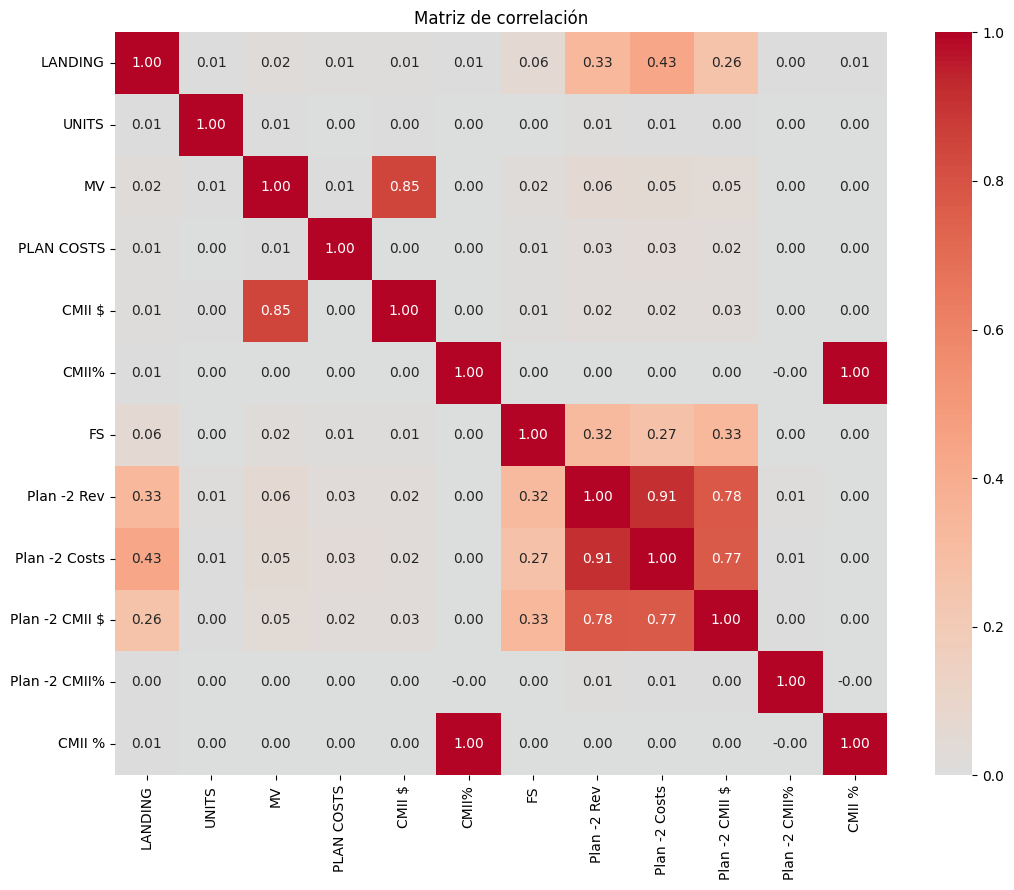

In [55]:
plt.figure(figsize=(11, 9))
sns.heatmap(df_filtrado.corr(), annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

La mayoría de los datos de PLAN, son los datos que tienen alta correlación, esto habla mucho sobre el portafolio que la compañía tiene y la atención a cuidar el margen, hace sentido que en los datos donde hay mayores costos, se compensa con más revenue

**PCA**

In [58]:
scaler = StandardScaler()
datos_escalados = scaler.fit_transform(df_filtrado)

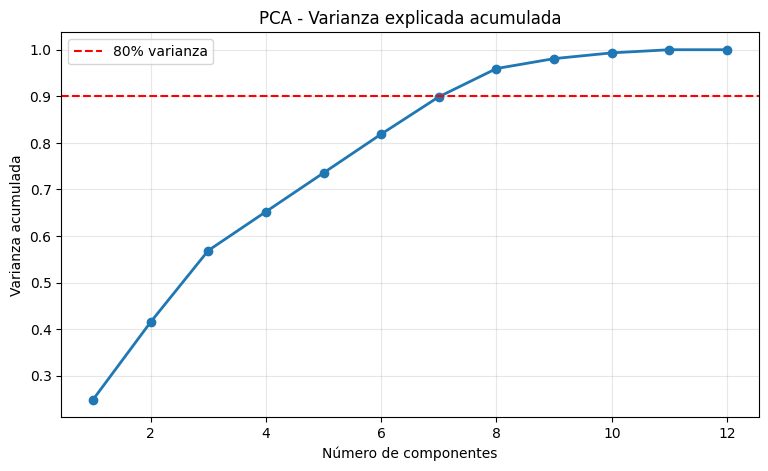

PC1:  24.87%  |  acumulado:  24.87%
PC2:  16.67%  |  acumulado:  41.54%
PC3:  15.36%  |  acumulado:  56.90%
PC4:   8.34%  |  acumulado:  65.23%
PC5:   8.33%  |  acumulado:  73.56%
PC6:   8.32%  |  acumulado:  81.89%
PC7:   8.00%  |  acumulado:  89.89%
PC8:   6.07%  |  acumulado:  95.96%
PC9:   2.13%  |  acumulado:  98.09%
PC10:   1.23%  |  acumulado:  99.32%
PC11:   0.68%  |  acumulado: 100.00%
PC12:   0.00%  |  acumulado: 100.00%


In [60]:
pca = PCA()
componentes = pca.fit_transform(datos_escalados)
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(varianza_acumulada)+1), varianza_acumulada, marker='o', linewidth=2)
plt.axhline(y=0.90, color='red', linestyle='--', label='80% varianza')
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.title("PCA - Varianza explicada acumulada")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

for i, (v, va) in enumerate(zip(varianza_explicada, varianza_acumulada), 1):
    print(f"PC{i}: {v*100:6.2f}%  |  acumulado: {va*100:6.2f}%")

Con esto nos quedamos con 8 componentes principales

In [61]:
n_componentes = 8
pca_final = PCA(n_components=n_componentes)
datos_reducidos = pca_final.fit_transform(datos_escalados)

df_reducido = pd.DataFrame(
    datos_reducidos,
    columns=[f"PC{i+1}" for i in range(n_componentes)]
)
print("Forma original:", df_filtrado.shape)
print("Forma reducida:", df_reducido.shape)
df_reducido.head()

Forma original: (14582, 12)
Forma reducida: (14582, 8)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,-0.147164,0.017639,-0.035550,-0.034377,-0.000324,-0.041833,0.320723,-0.339684
1,-0.005519,0.021237,-0.058105,0.000204,0.000357,0.000018,0.000828,-0.000864
2,-0.005519,0.021237,-0.058105,0.000204,0.000357,0.000018,0.000828,-0.000864
3,-0.147248,0.017636,-0.036366,-0.034431,-0.000322,-0.042210,0.320689,-0.339693
4,-0.147218,0.017621,-0.032341,-0.066485,-0.039805,-0.036578,0.317855,-0.339521


##INSTRUCCIONES C: Incluir conclusiones de la fase de "Preparación de los datos" en el contexto de la metodología CRISP-ML.

Analizando los datos, nos damos cuenta que a pesar de las multiples columnas con las que cuenta la vase de datos, al tratarse de registro de ventas muchas son descriptivas sobre origen, destino y tipo de venta. En realidad, la base de datos cuenta con poca información númerica y la que se encuentra gira entorno al tipo de producto y la rentabilidad del mismo. (Revenue - Costos) = Contribución Marginal, % de Contribución Marginal = (Revenue/Costos). Los primeros 3 componentes explican la mayoría de la información que es el Tamaño de proyecto planeado, el margen real y los ingresos.